# Generate random spatial distribution

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import cftime
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
from matplotlib import rc, colors, ticker
import matplotlib.transforms as transforms
from matplotlib.lines import Line2D
import matplotlib.dates as mdates
from matplotlib.colors import LogNorm
from matplotlib.colors import ListedColormap,Normalize
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
import cmweather
import seaborn as sns
import cartopy
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

In [2]:
# helper function for skinny box plots
def _q_stats(data):
    vals = np.array([v for v in data if not np.isnan(v)])
    if vals.size == 0:
        return np.nan, np.nan, np.nan, np.nan
    q1, q2, q3 = np.nanpercentile(vals, [25, 50, 75])
    mean = np.nanmean(vals)
    return q1, q2, q3, mean

In [3]:
# Define color-blind safe colors
cb_orange = [230/255, 159/255, 0]
cb_skyblue = [86/255, 180/255, 233/255]
cb_green = [0, 158/255, 115/255]
cb_yellow = [240/255, 228/255, 66/255]
cb_blue = [0, 114/255, 178/255]
cb_red = [213/255, 94/255, 0]
cb_purple = [204/255, 121/255, 167/255]


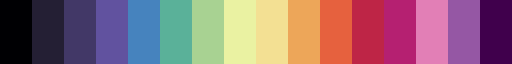

In [4]:
# Load colormap

# Read the colormap from a .txt file
def load_colormap_from_txt(file_path):
    # Load RGB values from the file
    rgb_values = np.loadtxt(file_path)
    return ListedColormap(rgb_values)

# Example usage
colormap_file = 'chase-spectral-rgb.txt'  # Replace with your .txt file path
radar_cmap = load_colormap_from_txt(colormap_file)

discrete_cmap = ListedColormap(radar_cmap(np.linspace(0, 1, 16)))
discrete_mask_cmap = discrete_cmap.copy()
discrete_mask_cmap.set_under(color='white') #set values below vmin to white
discrete_mask_cmap.set_bad(color='gray') #set missing (NaN) values to gray

discrete_mask_cmap

In [5]:
seapol = xr.open_dataset('/huracan/tank4/cornell/ORCESTRA/sea-pol/qc_data/level4v1.2/PICCOLO_level4_rainrate_2D.nc')
seapol

<xarray.Dataset> Size: 50GB
Dimensions:          (time: 8670, Y: 491, X: 491)
Coordinates:
  * X                (X) float32 2kB -2.45e+05 -2.44e+05 ... 2.44e+05 2.45e+05
  * Y                (Y) float32 2kB -2.45e+05 -2.44e+05 ... 2.44e+05 2.45e+05
    latitude         (time, Y, X) float32 8GB ...
    longitude        (time, Y, X) float32 8GB ...
  * time             (time) datetime64[ns] 69kB 2024-08-16T08:10:00 ... 2024-...
Data variables:
    DBZ              (time, Y, X) float32 8GB ...
    HID              (time, Y, X) float32 8GB ...
    RAINRATE         (time, Y, X) float32 8GB ...
    elevation_angle  (time, Y, X) float32 8GB ...
    grid_mapping     int32 4B ...
    heading          (time) float32 35kB ...
    start_time       (time) datetime64[ns] 69kB ...
    stop_time        (time) datetime64[ns] 69kB ...
Attributes: (12/15)
    Conventions:       CF-1.12
    institution:       Colorado State University
    creator_email:     mmbell@colostate.edu
    creator_id:        https://orcid.org/0000-0002-0496-331X
    project:           PICCOLO, BOWTIE, ORCESTRA
    platform:          RV METEOR
    ...                ...
    version:           v1.2
    title:             Level 4 Gridded Sea-Pol Radar Data Rainrate 2D
    creator_name:      Michael M. Bell, Brenda Dolan, Jennifer DeHart, Delián...
    summary:           This dataset contains the processed Level 3 Sea-Pol ra...
    source:            Colorado State University Sea-Pol radar
    instrument:        Colorado State University Sea-Pol radar

Define valid region mask

In [6]:
# extract one time step
time_map = np.datetime64('2024-09-08T16:20')
index_map = np.abs(pd.to_datetime(seapol.time) - time_map).argmin()
map = seapol.DBZ[index_map,:,:]
map

<xarray.DataArray 'DBZ' (Y: 491, X: 491)> Size: 964kB
[241081 values with dtype=float32]
Coordinates:
  * X          (X) float32 2kB -2.45e+05 -2.44e+05 ... 2.44e+05 2.45e+05
  * Y          (Y) float32 2kB -2.45e+05 -2.44e+05 ... 2.44e+05 2.45e+05
    latitude   (Y, X) float32 964kB ...
    longitude  (Y, X) float32 964kB ...
    time       datetime64[ns] 8B 2024-09-08T16:20:00
Attributes:
    valid_min:      -3.4028e+38
    valid_max:      3.4028e+38
    grid_mapping:   grid_mapping
    standard_name:  DBZ
    long_name:      Radar Reflectivity
    units:          dBZ
    cell_methods:   time: mean

In [7]:
#Find indices for X = 120 km, 60 km, and 12 km from center of the grid
ix120 = np.where(np.isclose(seapol.X, 120000))[0][0]
ix60 = np.where(np.isclose(seapol.X, 60000))[0][0]
ix12 = np.where(np.isclose(seapol.X, 12000))[0][0]
print(f"Index for X=120 km: {ix120}, X=60 km: {ix60}, X=12 km: {ix12}")

ixn120 = np.where(np.isclose(seapol.X, -120000))[0][0]
ixn60 = np.where(np.isclose(seapol.X, -60000))[0][0]
ixn12 = np.where(np.isclose(seapol.X, -12000))[0][0]
print(f"Index for X=-120 km: {ixn120}, X=-60 km: {ixn60}, X=-12 km: {ixn12}")

iy120 = np.where(np.isclose(seapol.Y, 120000))[0][0]
iy60 = np.where(np.isclose(seapol.Y, 60000))[0][0]
iy12 = np.where(np.isclose(seapol.Y, 12000))[0][0]
print(f"Index for Y=120 km: {iy120}, Y=60 km: {iy60}, Y=12 km: {iy12}")

iyn120 = np.where(np.isclose(seapol.Y, -120000))[0][0]
iyn60 = np.where(np.isclose(seapol.Y, -60000))[0][0]
iyn12 = np.where(np.isclose(seapol.Y, -12000))[0][0]
print(f"Index for Y=-120 km: {iyn120}, Y=-60 km: {iyn60}, Y=-12 km: {iyn12}")

Index for X=120 km: 365, X=60 km: 305, X=12 km: 257
Index for X=-120 km: 125, X=-60 km: 185, X=-12 km: 233
Index for Y=120 km: 365, Y=60 km: 305, Y=12 km: 257
Index for Y=-120 km: 125, Y=-60 km: 185, Y=-12 km: 233


In [8]:
#Find indices of valid grid points (where map is not NaN)
valid_mask = ~np.isnan(map)

In [9]:
# Generate 5000 random scenes

scenes = []
fa245 = np.zeros(5000)  # To store fractional area for each scene
fa120 = np.zeros(5000)  # To store fractional area within 120 km for each scene
fa60 = np.zeros(5000)  # To store fractional area within 60 km for each scene
fa12 = np.zeros(5000)  # To store fractional area within 12 km for each scene
is_ship = np.zeros(5000, dtype=bool)  # To store whether it's raining at the ship for each scene

valid_mask = np.asarray(valid_mask, dtype=bool)
n = int(valid_mask.sum())

for s in range(5000):
    #Initialize random seed for reproducibility
    rng = np.random.default_rng(seed=s)

    #For each grid point where valid_mask is True, randomly assign a value of 0 or 1
    scene = np.full(map.shape, np.nan)  # Initialize scene with NaN
    scene[valid_mask] = rng.integers(0, 2, size=n)  # Assign 0 or 1 to valid points
    scenes.append(scene)
    
    fa245[s] = np.nansum(scene) / np.sum(valid_mask)  # Calculate fractional area for this scene
    fa120[s] = np.nansum(scene[iyn120:iy120+1,ixn120:ix120+1]) / np.sum(valid_mask[iyn120:iy120+1,ixn120:ix120+1])  # Fractional area within 120 km
    fa60[s] = np.nansum(scene[iyn60:iy60+1,ixn60:ix60+1]) / np.sum(valid_mask[iyn60:iy60+1,ixn60:ix60+1])  # Fractional area within 60 km
    fa12[s] = np.nansum(scene[iyn12:iy12+1,ixn12:ix12+1]) / np.sum(valid_mask[iyn12:iy12+1,ixn12:ix12+1])  # Fractional area within 12 km
    is_ship[s] = scene[scene.shape[0] // 2, scene.shape[1] // 2] == 1  # Check if it's raining at the ship

Calculate statistics

In [10]:
# how many scenes is it raining at the ship?
num_raining_at_ship = np.sum(is_ship)
print(f"Number of scenes where it's raining at the ship: {num_raining_at_ship} out of 5000")

Number of scenes where it's raining at the ship: 2459 out of 5000


In [11]:
# fractional area coverage when raining at the ship over different ranges
fa_ship245 = fa245[is_ship]
fa_ship120 = fa120[is_ship]
fa_ship60 = fa60[is_ship]
fa_ship12 = fa12[is_ship]

#fractional area coverage when not raining at the ship over different ranges
fa_noship245 = fa245[~is_ship]
fa_noship120 = fa120[~is_ship]
fa_noship60 = fa60[~is_ship]
fa_noship12 = fa12[~is_ship]

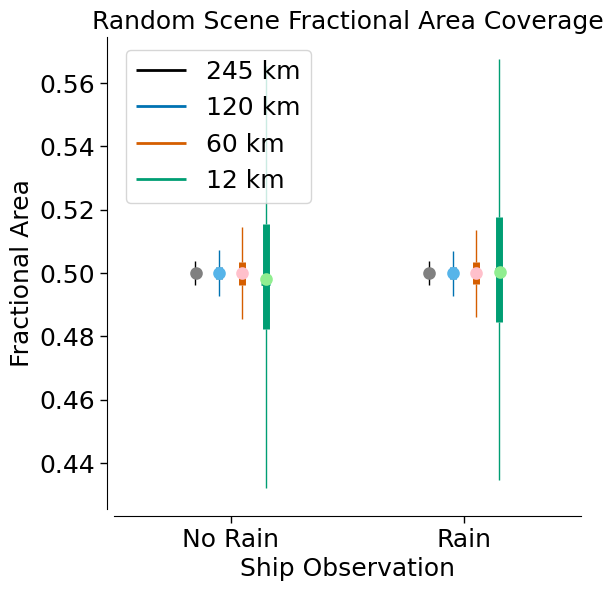

In [12]:
fig, axs = plt.subplots(figsize=(6,6))

plot_items = [(axs, fa_noship245, 'black', 'gray','245 km'),
              (axs, fa_noship120, cb_blue, cb_skyblue,'120 km'),
              (axs, fa_noship60, cb_red, 'pink','60 km'),
              (axs, fa_noship12, cb_green, 'lightgreen','12 km')]

shift = 0
for ax, data_list, box_color, dot_color, legend_label in plot_items:
    q1, q2, q3, mean_val = _q_stats(data_list)
    if np.isnan(q1):
        continue
    xpos_frac = 0.175 + shift #move a bit closer to the right edge
    dx_frac = 0.01 #horizontal half-width
    
    trans = transforms.blended_transform_factory(ax.transAxes, ax.transData)
    
    # central IQR bar
    iqr_line = Line2D([xpos_frac, xpos_frac], [q1, q3],
                      transform=trans, color=box_color,
                      linewidth=5, solid_capstyle='butt', zorder=4)
    ax.add_line(iqr_line)
    # median horizontal bar
    med_line = Line2D([xpos_frac - dx_frac, xpos_frac + dx_frac], [q2, q2],
                      transform=trans, color=box_color,
                      linewidth=2, solid_capstyle='butt', label = legend_label, zorder=5)
    ax.add_line(med_line)
    # mean marker circle
    ax.scatter([xpos_frac + dx_frac * .045], [mean_val], transform=trans,
               marker='o', edgecolor=dot_color, facecolor=dot_color, s=50,
               linewidths=2, zorder=6)
    # whiskers at 1.5 * IQR
    iqr = q3 - q1
    data_vals = np.array([v for v in data_list if not np.isnan(v)])
    if data_vals.size == 0:
        continue
    whisker_low = max(q1 - 1.5 * iqr, data_vals.min())
    whisker_high = min(q3 + 1.5 * iqr, data_vals.max())
    # whisker lines
    whisk_low_line = Line2D([xpos_frac, xpos_frac], [q1, whisker_low],
                            transform=trans, color=box_color,
                            linewidth=1, solid_capstyle='butt', zorder=3)
    whisk_high_line = Line2D([xpos_frac, xpos_frac], [q3, whisker_high],
                             transform=trans, color=box_color,
                             linewidth=1, solid_capstyle='butt', zorder=3)
    ax.add_line(whisk_low_line)
    ax.add_line(whisk_high_line)
    
    shift += 0.05
    
plot_items = [(axs, fa_ship245, 'black', 'gray'),
              (axs, fa_ship120, cb_blue, cb_skyblue),
              (axs, fa_ship60, cb_red, 'pink'),
              (axs, fa_ship12, cb_green, 'lightgreen')]

shift = 0
for ax, data_list, box_color, dot_color in plot_items:
    q1, q2, q3, mean_val = _q_stats(data_list)
    if np.isnan(q1):
        continue
    xpos_frac = 0.675 + shift #move a bit closer to the right edge
    dx_frac = 0.01 #horizontal half-width
    
    trans = transforms.blended_transform_factory(ax.transAxes, ax.transData)
    
    # central IQR bar
    iqr_line = Line2D([xpos_frac, xpos_frac], [q1, q3],
                      transform=trans, color=box_color,
                      linewidth=5, solid_capstyle='butt', zorder=4)
    ax.add_line(iqr_line)
    # median horizontal bar
    med_line = Line2D([xpos_frac - dx_frac, xpos_frac + dx_frac], [q2, q2],
                      transform=trans, color=box_color,
                      linewidth=2, solid_capstyle='butt', zorder=5)
    ax.add_line(med_line)
    # mean marker circle
    ax.scatter([xpos_frac + dx_frac * .045], [mean_val], transform=trans,
               marker='o', edgecolor=dot_color, facecolor=dot_color, s=50,
               linewidths=2, zorder=6)
    # whiskers at 1.5 * IQR
    iqr = q3 - q1
    data_vals = np.array([v for v in data_list if not np.isnan(v)])
    if data_vals.size == 0:
        continue
    whisker_low = max(q1 - 1.5 * iqr, data_vals.min())
    whisker_high = min(q3 + 1.5 * iqr, data_vals.max())
    # whisker lines
    whisk_low_line = Line2D([xpos_frac, xpos_frac], [q1, whisker_low],
                            transform=trans, color=box_color,
                            linewidth=1, solid_capstyle='butt', zorder=3)
    whisk_high_line = Line2D([xpos_frac, xpos_frac], [q3, whisker_high],
                             transform=trans, color=box_color,
                             linewidth=1, solid_capstyle='butt', zorder=3)
    ax.add_line(whisk_low_line)
    ax.add_line(whisk_high_line)
    
    shift += 0.05

    
# set plot attributes
axs.set_title('Random Scene Fractional Area Coverage',fontsize=18)
axs.set_ylabel('Fractional Area',fontsize=18)
axs.set_xlabel('Ship Observation',fontsize=18)
axs.set_xticks([0.25,0.75])
axs.set_xlim(0,1)
axs.set_xticklabels(['No Rain','Rain'],fontsize=18)
axs.tick_params(labelsize=18)
plt.legend(fontsize=18, loc='upper left')


sns.set_context('paper') 
sns.despine(offset=5)
plt.tight_layout()  # Adjust subplots to fit into figure area. 

# Randomly re-shuffle a given number of raining pixels

In [27]:
# Define fa bins
fa_bins = np.arange(0, 1.05, 0.05)
fa_bins

array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 ,
       0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  ])

In [14]:
# Define N bins
N_bins245 = fa_bins*np.sum(valid_mask)  # Convert fractional area bins to number of grid points for 245 km
N_bins120 = fa_bins*np.sum(valid_mask[iyn120:iy120+1,ixn120:ix120+1])  # Convert fractional area bins to number of grid points for 120 km
N_bins60 = fa_bins*np.sum(valid_mask[iyn60:iy60+1,ixn60:ix60+1])  # Convert fractional area bins to number of grid points for 60 km
N_bins12 = fa_bins*np.sum(valid_mask[iyn12:iy12+1,ixn12:ix12+1])  # Convert fractional area bins to number of grid points for 12 km

In [15]:
# get the coordinates of valid_mask
valid_coords = np.argwhere(valid_mask)

In [47]:
# generate 1000 random scenes for each value of N
scenes_by_N245 = {N: [] for N in N_bins245}
frac_ship_byN = np.zeros(len(N_bins245))  # To store fraction of scenes with rain at the ship for each N
for iN, N in enumerate(N_bins245):
    is_ship_by_scene = np.zeros(1000, dtype=bool)  # To store whether it's raining at the ship for each scene
    for s in range(1000):
        #Initialize random seed for reproducibility
        rng = np.random.default_rng(seed=s)
        random_coords = valid_coords[rng.choice(valid_coords.shape[0], size=int(N), replace=False)]
        random_scene = np.full(map.shape, np.nan)  # Initialize scene with NaN
        random_scene[valid_mask] = 0  # Set all valid points to 0
        for coord in random_coords:
            random_scene[coord[0], coord[1]] = 1  # Set chosen coordinates to 1
        scenes_by_N245[N].append(random_scene)
        is_ship_by_scene[s] = (random_scene[random_scene.shape[0] // 2, random_scene.shape[1] // 2] == 1)  # Check if it's raining at the ship
    frac_ship_byN[iN] = np.sum(is_ship_by_scene) / len(is_ship_by_scene)  # Calculate fraction of scenes with rain at the ship for this N

In [48]:
frac_ship_byN

array([0.   , 0.055, 0.097, 0.144, 0.193, 0.238, 0.282, 0.335, 0.381,
       0.438, 0.487, 0.543, 0.6  , 0.649, 0.693, 0.737, 0.792, 0.852,
       0.902, 0.945, 1.   ])

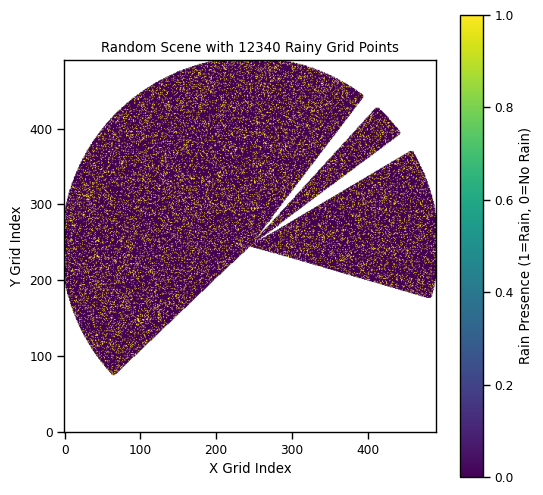

In [49]:
# plot to check
plt.figure(figsize=(6,6))
plt.imshow(scenes_by_N245[N_bins245[3]][5], origin='lower')
plt.colorbar(label='Rain Presence (1=Rain, 0=No Rain)')
plt.title('Random Scene with ' + str(N_bins245[2].astype(int)) + ' Rainy Grid Points')
plt.xlabel('X Grid Index')
plt.ylabel('Y Grid Index')
plt.show()

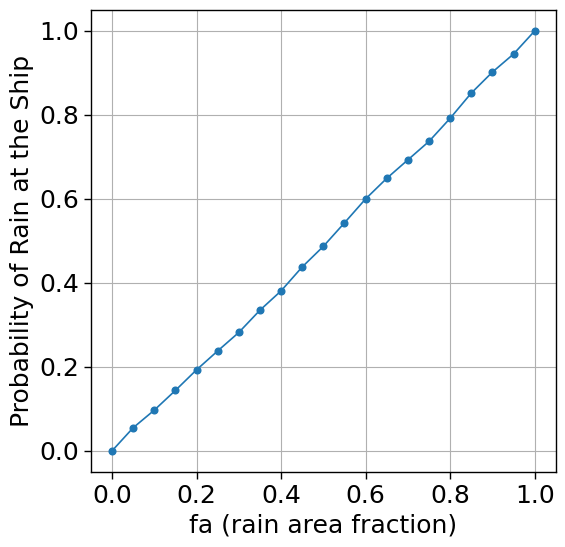

In [50]:
# plot fraction of scenes with rain at the ship vs N
plt.figure(figsize=(6,6))
plt.plot(fa_bins, frac_ship_byN, marker='o')
plt.xlabel('fa (rain area fraction)', fontsize=18)
plt.ylabel('Probability of Rain at the Ship', fontsize=18)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.grid()
plt.show()